# Complexity of the Avoided Crossing CASE

#### Imports

In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from src.annealing_utils import (
    get_driver_hamiltonian,
    get_longitudinal_hamiltonian,
    computational_basis,
)
from src.schedule_utils import SchedulerModel, Schedule
from ManyBodyQutip.qutip_class import SpinOperator
from src.utils import Sector
from src.optimalcontrol_magic_constrain_utils import (
    JaxSchedulerModelMagic,
    JaxTrainerMagic,
)
import pickle

## Initialization of the target Hamiltonian

#### Hyperapameters

In [157]:
import numpy as np
from src.annealing_utils import get_longitudinal_hamiltonian, get_driver_hamiltonian


def mwis_jij_hz(n0, n1, dW, Jzz):
    n = n0 + n1
    G0 = list(range(n0))
    G1 = list(range(n0, n0 + n1))

    jij = np.zeros((n, n))
    for i in G0:
        for j in G1:
            jij[i, j] = Jzz
            jij[j, i] = Jzz

    h0 = n1 * Jzz - 2 * (1 + dW) / n0
    h1 = n0 * Jzz - 2 / n1

    hz = np.zeros(n)
    for i in G0:
        hz[i] = +h0
    for j in G1:
        hz[j] = +h1

    return jij, hz


# ── Example: n0=2, n1=3, matching the paper's 5-qubit instance ───────────────
n0, n1 = 2, 3
dW = 0.1  # small weight imbalance → perturbative crossing
Jzz = 5.33  # edge penalty (closed-system example in paper)

jij, hz = mwis_jij_hz(n0, n1, dW, Jzz)

print("Jij matrix:")
print(np.round(jij, 3))
print("\nhz vector:")
print(np.round(hz, 3))

Jij matrix:
[[0.   0.   5.33 5.33 5.33]
 [0.   0.   5.33 5.33 5.33]
 [5.33 5.33 0.   0.   0.  ]
 [5.33 5.33 0.   0.   0.  ]
 [5.33 5.33 0.   0.   0.  ]]

hz vector:
[14.89  14.89   9.993  9.993  9.993]


#### Hamiltonian Initialization

In [158]:
# ── Feed into your src functions ─────────────────────────────────────────────
nqubits = n0 + n1
target_hamiltonian = get_longitudinal_hamiltonian(jij, hz)  # sparse scipy matrix
driver_hamiltonian = get_driver_hamiltonian(nqubits=nqubits)  # sparse scipy matrix

# ── Verify: ground state energy ──────────────────────────────────────────────
from scipy.sparse.linalg import eigsh

from scipy.sparse.linalg import eigsh
import numpy as np

vals = np.sort(target_hamiltonian.diagonal())
idxs = np.argsort(target_hamiltonian.diagonal())


basis = computational_basis(nqubits)  # shape (2^nqubits, nqubits)

for k in range(4):
    print(f"\nEigenstate {k} in computational basis:")
    # Get the eigenvector (shape (2^nqubits,))
    eigenstate_k = basis[idxs[k]]
    print(eigenstate_k)
    print("Eigenvalue:", vals[k])
    print("\n")


Eigenstate 0 in computational basis:
[0 0 1 1 1]
Eigenvalue: (-32.17999999999999+0j)



Eigenstate 1 in computational basis:
[1 1 0 0 0]
Eigenvalue: (-31.779999999999998+0j)



Eigenstate 2 in computational basis:
[1 1 1 0 0]
Eigenvalue: (-30.44666666666667+0j)



Eigenstate 3 in computational basis:
[1 1 0 1 0]
Eigenvalue: (-30.44666666666667+0j)




#### Analysis of the spectrum of the target hamiltonian

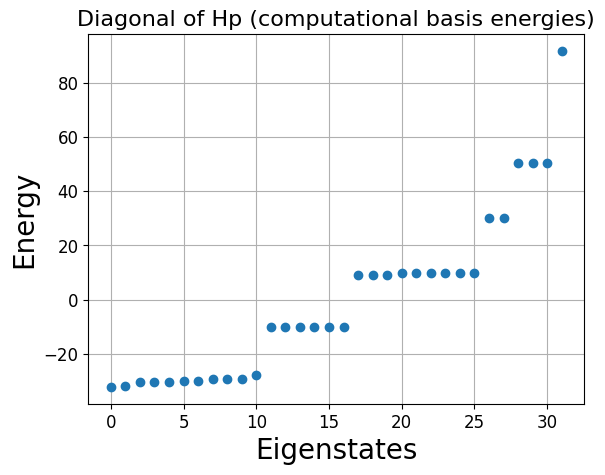

In [159]:
plt.plot(vals, "o")
plt.xlabel("Eigenstates", fontsize=20)
plt.ylabel("Energy", fontsize=20)
plt.title("Diagonal of Hp (computational basis energies)", fontsize=16)
plt.tick_params(axis="both", which="major", labelsize=12)
plt.grid()
plt.show()

#### Time evolution

In [160]:
# ── time evolution parameters ─────────────────────────────────────────────────
nlevels = 10
tau = 200
time_steps = int(100 * tau)
time = np.linspace(0, tau, time_steps)
delta_t = time[1] - time[0]

In [161]:
from scipy.sparse.linalg import eigsh, expm_multiply

# ── initial state ─────────────────────────────────────────────────────────────
dim = 2**nqubits
psi_init = np.ones(dim, dtype=complex) / np.sqrt(dim)
# ── initialization ────────────────────────────────────────────────────────────
spectrum = np.zeros((time_steps, nlevels))
energy = np.zeros(time_steps)
probabilities = np.zeros((time_steps, nlevels))
psi_history = np.zeros((time_steps, dim), dtype=complex)
eigenstates_history = np.zeros((time_steps, dim, nlevels), dtype=complex)

eigenstates_prev = None
psi = psi_init.copy()

# ── time evolution ────────────────────────────────────────────────────────────
for i, t in enumerate(time):

    hamiltonian_t = (1 - t / tau) * driver_hamiltonian + (t / tau) * target_hamiltonian
    psi = expm_multiply(-1j * delta_t * hamiltonian_t, psi)

    # ── diagonalize ───────────────────────────────────────────────────────
    spectrum_t, eigenstates_t = eigsh(
        hamiltonian_t.astype(complex), which="SA", k=nlevels
    )
    order = np.argsort(spectrum_t)
    spectrum[i] = spectrum_t[order]
    eigenstates_raw = eigenstates_t[:, order].astype(complex)  # raw — for probabilities
    eigenstates_history[i] = eigenstates_raw
    # overlap
    probabilities[i] = (
        np.einsum("i,ia->a", psi.conj(), eigenstates_raw)
        * np.einsum("i,ia->a", psi.conj(), eigenstates_raw).conj()
    )
    energy[i] = np.real(np.vdot(psi, hamiltonian_t @ psi))
    psi_history[i] = psi

print(probabilities[-1, 0])
print(spectrum.shape)
print(
    time[np.argmin(spectrum[:, 2] - spectrum[:, 0])],
    np.min(spectrum[:, 2] - spectrum[:, 0]),
)

min_time_gap = time[np.argmin(spectrum[:, 2] - spectrum[:, 0])]


print("final energy:", energy[-1])

/tmp/ipykernel_197304/1023334199.py:31: ComplexWarning: Casting complex values to real discards the imaginary part
  probabilities[i] = (


0.10801651934622113
(20000, 10)
119.65598279913996 1.1004542557253387
final energy: -31.82174302828547


Check the results

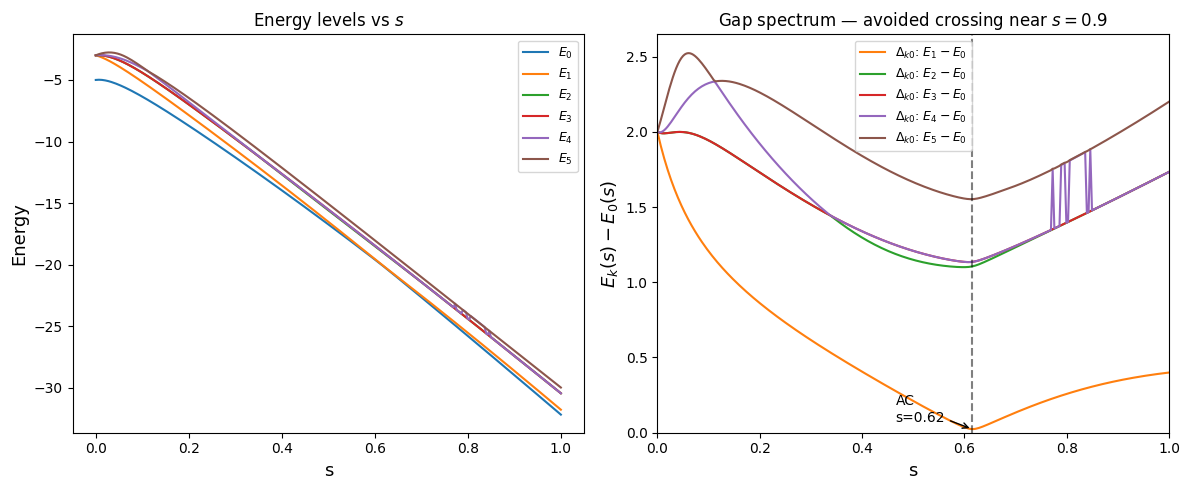

Minimum gap Δ₁₀ = 0.024163 at s = 0.615


In [162]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse.linalg import eigsh
from scipy.sparse import csr_matrix

n_levels = 6
n = n1 + n0
# --- Build Hamiltonians ---
jij, hz = mwis_jij_hz(n0, n1, dW, Jzz)
Hp = get_longitudinal_hamiltonian(jij, hz)
Hd = get_driver_hamiltonian(n)

# --- Sweep s ---
s_vals = np.linspace(0, 1, 300)
spectra = np.zeros((len(s_vals), n_levels))

for idx, s in enumerate(s_vals):
    H = (1 - s) * Hd + s * Hp
    vals = eigsh(H, k=n_levels, which="SA", return_eigenvectors=False)
    spectra[idx] = np.sort(vals.real)

E0 = spectra[:, 0]  # ground state energy at each s

# --- Plot 1: Raw energy levels ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
for k in range(n_levels):
    ax.plot(s_vals, spectra[:, k], label=f"$E_{k}$")
ax.set_xlabel("s", fontsize=13)
ax.set_ylabel("Energy", fontsize=13)
ax.set_title("Energy levels vs $s$")
ax.legend(fontsize=9)

# --- Plot 2: Gaps Δ_k0 = E_k - E_0  (what the paper plots) ---
ax = axes[1]
colors = ["C1", "C2", "C3", "C4", "C5"]
for k in range(1, n_levels):
    gap = spectra[:, k] - E0
    ax.plot(s_vals, gap, color=colors[k - 1], label=f"$\\Delta_{{k0}}$: $E_{k}-E_0$")

ax.set_xlabel("s", fontsize=13)
ax.set_ylabel("$E_k(s) - E_0(s)$", fontsize=13)
ax.set_title("Gap spectrum — avoided crossing near $s=0.9$")
ax.legend(fontsize=9)
ax.set_xlim(0, 1)
ax.set_ylim(0, None)

# Mark the minimum gap
min_gap = spectra[:, 1] - E0
s_mingap = s_vals[np.argmin(min_gap)]
ax.axvline(
    s_mingap, color="k", linestyle="--", alpha=0.5, label=f"min gap @ s={s_mingap:.2f}"
)
ax.annotate(
    f"AC\ns={s_mingap:.2f}",
    xy=(s_mingap, min_gap.min()),
    xytext=(s_mingap - 0.15, min_gap.min() + 0.05),
    arrowprops=dict(arrowstyle="->", color="black"),
    fontsize=10,
)

plt.tight_layout()
plt.savefig("avoided_crossing.png", dpi=150)
plt.show()

print(f"Minimum gap Δ₁₀ = {min_gap.min():.6f} at s = {s_mingap:.3f}")

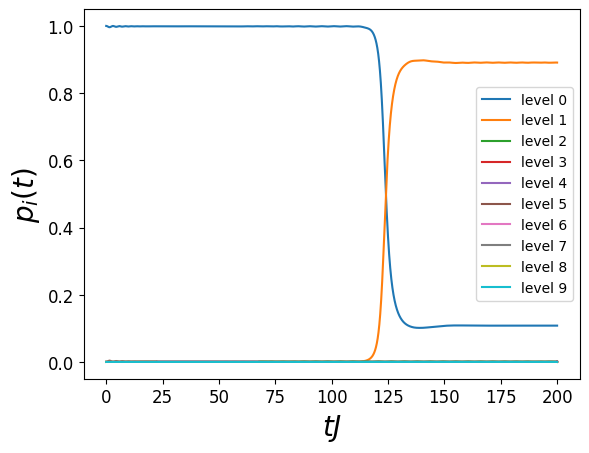

In [163]:
for i in range(nlevels):
    plt.plot(time, probabilities[:, i], label=f"level {i}")
plt.xlabel(r"$t J$", fontsize=20)
plt.ylabel(r"$p_i(t)$", fontsize=20)
plt.tick_params(axis="both", which="major", labelsize=12)
plt.legend()
plt.show()

#### Compute Measure of Stabilizerness

In [164]:
from src.jax_utils import SREJax
from src.utils import EntanglementEntropy
from tqdm import trange

# build once — reuse for all states
sre = SREJax(n_qubits=nqubits, batch_size=4096)
entanglement_entropy = EntanglementEntropy(nqubits=nqubits, n_A=nqubits // 2)

# single state
magic = []
magic_gs_level = []
entanglememt_entropy_history = []
entanglement_entropy_gs_level_history = []
for i in trange(time_steps):
    state = psi_history[i]
    magic.append(sre((state)))
    magic_gs_level.append(sre((eigenstates_history[i, :, 0])))
    entanglememt_entropy_history.append(entanglement_entropy.von_neumann((state)))
    entanglement_entropy_gs_level_history.append(
        entanglement_entropy.von_neumann((eigenstates_history[i, :, 0]))
    )

Building Pauli index tables for n=5 (1,024 Paulis)...
Done.
Bipartition: A=2 qubits (4d), B=3 qubits (8d)


100%|██████████| 20000/20000 [00:16<00:00, 1186.12it/s]


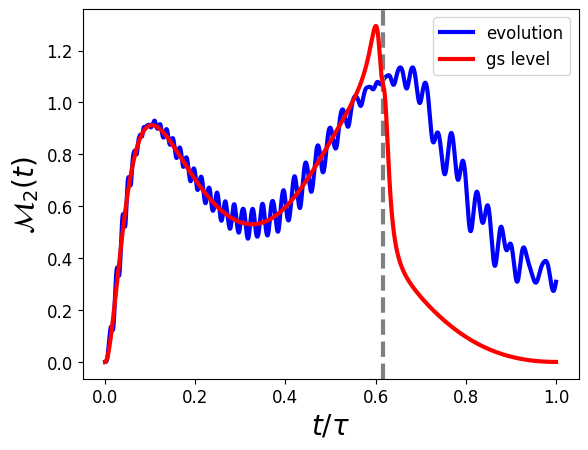

In [165]:
plt.plot(time / tau, magic, label="evolution", color="blue", linestyle="-", linewidth=3)

plt.axvline(s_mingap, linestyle="--", color="grey", lw=3)
plt.plot(
    time / tau,
    magic_gs_level,
    label="gs level",
    color="red",
    linestyle="-",
    linewidth=3,
)
plt.xlabel(r"$t/\tau$", fontsize=20)
plt.ylabel(r"$\mathcal{M}_2(t)$", fontsize=20)
plt.legend(fontsize=12)
plt.tick_params(axis="both", which="major", labelsize=12)
plt.show()

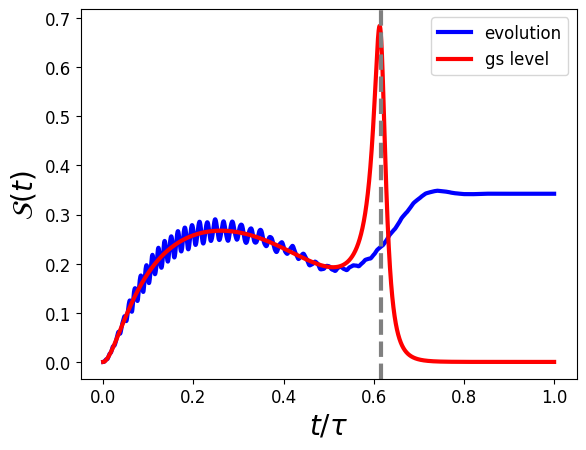

In [166]:
plt.plot(
    time / tau,
    entanglememt_entropy_history,
    label="evolution",
    color="blue",
    linestyle="-",
    linewidth=3,
)
plt.plot(
    time / tau,
    entanglement_entropy_gs_level_history,
    label="gs level",
    color="red",
    linestyle="-",
    linewidth=3,
)
plt.axvline(s_mingap, linestyle="--", color="grey", lw=3)
plt.xlabel(r"$t/\tau$", fontsize=20)
plt.ylabel(r"$\mathcal{S}(t)$", fontsize=20)
plt.legend(fontsize=12)
plt.tick_params(axis="both", which="major", labelsize=12)
plt.show()

In [167]:
from curses.ascii import SP

_, eigenstates_target_hamiltonian = eigsh(
    target_hamiltonian.astype(complex), which="SA", k=4
)
print(sre((eigenstates_target_hamiltonian[:, 0])))

1.7763568394002505e-15


## Optimal Control Method

##### Get Hyperparameters

In [169]:
number_parameters = 2
type = "LZS"

#### Jax optimization (optional)

In [ ]:
from src.jax_utils import JaxSchedulerModel, JaxTrainer

model = JaxSchedulerModel(
    initial_state=psi_init,
    target_hamiltonian=target_hamiltonian,
    initial_hamiltonian=driver_hamiltonian,
    reference_hamiltonian=target_hamiltonian,
    tf=tau,
    nsteps=time_steps,
    number_of_parameters=number_parameters,
    type=type,
    seed=42,
    mode="annealing ansatz",
    random=False,
)

trainer = JaxTrainer(model, maxiter=500, tol=1e-6, ftol=1e-5, gtol=1e-4, verbose=True)
results = trainer.run()

h_driver = results["h_driver"]
h_target = results["h_target"]
psi_final = results["psi"]
energy = results["energy"]  # already in physical units

JIT compilation done.


##### Jax with Magic (Optional)

In [ ]:
model = JaxSchedulerModelMagic(
    initial_state=psi_init,
    target_hamiltonian=target_hamiltonian,
    initial_hamiltonian=driver_hamiltonian,
    reference_hamiltonian=target_hamiltonian,
    tf=tau,  # total annealing time
    number_of_parameters=number_parameters,  # Fourier modes per schedule
    nsteps=time_steps,  # time steps
    type=type,  # 'fourier', 'F-CRAB', or 'power law'
    seed=42,
    lambda_magic=100,  # 0.0 = pure energy minimization
    magic_batch_size=4096,  # tune for memory
    random=False,  # random parameter initialization
)

# ── 4. Run optimization ───────────────────────────────────────────────────────
trainer = JaxTrainerMagic(
    model=model,
    maxiter=300,
    tol=1e-6,
    ftol=1e-9,
    gtol=1e-6,
    verbose=True,
)

results = trainer.run()

In [80]:
print(tau, number_parameters, time_steps, type)
print(psi_init.shape, psi_init.dtype)
print(
    target_hamiltonian_s.shape,
)
print(
    driver_hamiltonian_s.shape,
)

0.5 5 50 cumulative
(32,) complex128
(32, 32)
(32, 32)


#### Check the results

(-3.4746957087340062+3.5953427836168137j)


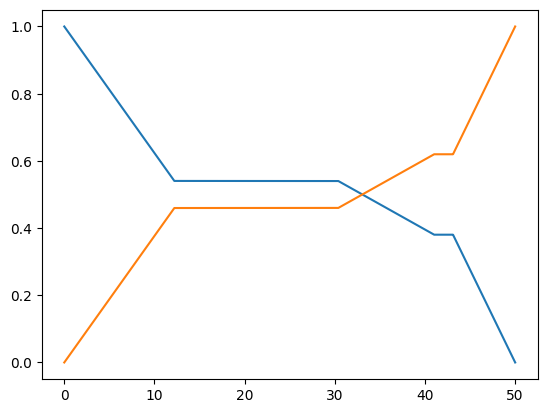

(-32.48107375987841+0j)


In [128]:
# ── energy + state history for both schedules ─────────────────────────────────
energy_linear = np.zeros(time_steps)
energy_optimal = np.zeros(time_steps)
psi_linear_history = np.zeros((time_steps, psi_init.shape[0]), dtype=complex)
psi_optimal_history = np.zeros((time_steps, psi_init.shape[0]), dtype=complex)

# optimal
h_driver, h_target = model.get_driving()

# initialize the state
_, psi = eigsh(driver_hamiltonian.astype(complex), which="SA", k=1)
psi_init = psi[:, 0].astype(complex)
print(psi_init.dot(h_driver[0] * driver_hamiltonian.dot(psi_init)))

plt.plot(time, h_driver)
plt.plot(time, h_target)
plt.show()


# initialization
psi = psi_init.copy()
psi_history_optimalcontrol = np.zeros((time_steps, psi_init.shape[0]), dtype=complex)
for i, t in enumerate(time):

    hamiltonian_t = h_driver[i] * driver_hamiltonian + target_hamiltonian * h_target[i]
    psi = expm_multiply(-1j * delta_t * hamiltonian_t, psi)
    psi_history_optimalcontrol[i] = psi
    # for r in range(nlevels):
    #    probabilities_optimalcontrol[i,r]=(eigenstates_history[i,:,r].conj().T.dot(psi))*np.conjugate((eigenstates_history[i,:,r].conj().T.dot(psi)))

print(psi.conj().dot(target_hamiltonian.dot(psi)))

##### Warm Starting

In [16]:
import numpy as np
from scipy.sparse.linalg import eigsh
from src.sparse_grape_method import SparseGRAPEModel, SparseGRAPETrainer


def get_driver_ground_state(driver_hamiltonian):
    """
    Returns the true ground state of the driver Hamiltonian.

    This is NOT the same as the uniform superposition np.ones(dim)/sqrt(dim)
    for n > 1 qubits with a transverse-field driver — the two only coincide
    when all driver eigenvalues are degenerate, which is not the case here.
    Using the wrong initial state shifts the gradient landscape seen by GRAPE
    and prevents convergence.
    """
    _, psi = eigsh(driver_hamiltonian.astype(complex), which="SA", k=1)
    return psi[:, 0].astype(complex)


def run_fcrab_warm_start(
    psi_init,
    target_hamiltonian,  # renamed: no _s suffix, full space
    driver_hamiltonian,  # renamed: no _s suffix, full space
    tau,
    time_steps,
    dim_schedule=[2, 4, 8, 16, 32],
    nr=5,
    maxiter=500,
    ftol=1e-9,
    gtol=1e-9,
    verbose=True,
):
    """
    Progressive warm-start F-CRAB optimisation, matching the notebook exactly.

    Key invariants
    --------------
    best_params layout : [a_drv_0, …, a_drv_{Nc-1},  a_tgt_0, …, a_tgt_{Nc-1}]
                         i.e. first Nc entries = driver coefficients,
                              next  Nc entries = target coefficients.

    When promoting from Nc_prev → Nc:
        init_params[:Nc_prev]          ← best_params[:Nc_prev]          (old driver)
        init_params[Nc : Nc+Nc_prev]   ← best_params[Nc_prev : 2*Nc_prev]  (old target)
        new slots are zero-initialised.

    best_omegas always has shape (Nc_current,) — the frequencies that go with
    the current best_params.  They are prepended to each next level's new
    random frequencies so the optimiser inherits the converged landscape.
    """
    best_params = None
    best_omegas = None
    best_energy = np.inf
    best_psi = None
    best_h_driver = None
    best_h_target = None

    for level_idx, dim in enumerate(dim_schedule):
        # number of modes that were already optimised at the previous level
        dim_prev = dim_schedule[level_idx - 1] if level_idx > 0 else 0
        delta = dim - dim_prev  # new modes added at this level

        if verbose:
            print(f"\n{'='*52}")
            print(f"  N_c = {dim}  (+{delta} new modes, {nr} restarts)")
            print(f"{'='*52}")

        level_best_energy = np.inf
        level_best_params = None
        level_best_omegas = None
        level_best_psi = None
        level_best_h_driver = None
        level_best_h_target = None

        for restart in range(nr):
            rng = np.random.default_rng()  # fresh seed each restart

            # ── frequencies ──────────────────────────────────────────────────
            # Only the *new* modes get randomised frequencies.
            # The old (converged) frequencies are inherited unchanged.
            new_omegas = (
                np.pi
                * np.arange(dim_prev + 1, dim + 1)
                * (1.0 + rng.uniform(-0.5, 0.5, delta))
                / tau
            )

            full_omegas = (
                np.concatenate([best_omegas, new_omegas])
                if best_omegas is not None
                else new_omegas
            )

            # ── parameter warm-start ──────────────────────────────────────────
            # Layout: [a_drv(dim), a_tgt(dim)]
            # Carry over old driver and target coefficients; zero the new slots.
            init_params = np.zeros(2 * dim)
            if best_params is not None:
                # old driver amplitudes
                init_params[:dim_prev] = best_params[:dim_prev]
                # old target amplitudes
                # NOTE: in best_params the target block starts at index dim_prev
                #       (size of the *previous* dim, not the current dim).
                init_params[dim : dim + dim_prev] = best_params[dim_prev : 2 * dim_prev]

            # ── model ─────────────────────────────────────────────────────────
            model = SparseGRAPEModel(
                initial_state=psi_init,
                target_hamiltonian=target_hamiltonian,
                initial_hamiltonian=driver_hamiltonian,
                reference_hamiltonian=target_hamiltonian,
                tf=tau,
                number_of_parameters=dim,
                nsteps=time_steps,
                type="F-CRAB",
                seed=42,
                mode="annealing ansatz",
                random=False,
            )

            # Override frequencies and recompute the sin basis.
            # This must happen AFTER model construction (which sets its own
            # default omegas) and BEFORE trainer.run() reads _sin_basis.
            model.omegas = full_omegas
            model._sin_basis = np.sin(np.outer(full_omegas, model.time))
            model.parameters = init_params.copy()

            # ── optimise ──────────────────────────────────────────────────────
            trainer = SparseGRAPETrainer(
                model,
                maxiter=maxiter,
                ftol=ftol,
                gtol=gtol,
                verbose=verbose,
            )
            res = trainer.run()

            if verbose:
                print(f"  └─ restart {restart+1}/{nr}  E = {res['energy']:.8f}")

            if res["energy"] < level_best_energy:
                level_best_energy = res["energy"]
                level_best_params = res["parameters"].copy()
                level_best_omegas = full_omegas.copy()
                level_best_psi = res["psi"].copy()
                level_best_h_driver = res["h_driver"].copy()
                level_best_h_target = res["h_target"].copy()

        # promote this level's best if it beats the global best
        if level_best_energy < best_energy:
            best_energy = level_best_energy
            best_params = level_best_params
            best_omegas = level_best_omegas
            best_psi = level_best_psi
            best_h_driver = level_best_h_driver
            best_h_target = level_best_h_target

        if verbose:
            print(f"\n  → best energy at N_c={dim}: {best_energy:.8f}")

    return {
        "h_driver": best_h_driver,
        "h_target": best_h_target,
        "energy": best_energy,
        "psi": best_psi,
        "parameters": best_params,
        "omegas": best_omegas,
    }


# ── usage ─────────────────────────────────────────────────────────────────────
# CRITICAL: psi_init must be the actual GS of the driver, not the uniform
# superposition.  The two differ for n > 1 qubits.
#
#   WRONG:  psi_init = np.ones(dim, dtype=complex) / np.sqrt(dim)
#   RIGHT:  psi_init = get_driver_ground_state(driver_hamiltonian)

if __name__ == "__main__":
    # these would be defined in your study script
    psi_init = get_driver_ground_state(driver_hamiltonian)

    results = run_fcrab_warm_start(
        psi_init=psi_init,
        target_hamiltonian=target_hamiltonian,
        driver_hamiltonian=driver_hamiltonian,
        tau=tau,
        time_steps=time_steps,
        dim_schedule=[2, 4, 8, 16, 32],
        nr=5,
        maxiter=500,
        ftol=1e-9,
        gtol=1e-9,
        verbose=True,
    )

    h_driver = results["h_driver"]
    h_target = results["h_target"]
    psi_final = results["psi"]
    energy = results["energy"]


  N_c = 2  (+2 new modes, 5 restarts)
  Initial energy    : -30.680804
  Gradient norm     : 1.605334e+00


KeyboardInterrupt: 

In [41]:
h_driver = results["h_driver"]
h_target = results["h_target"]

psi = psi_init.copy()
psi_history_optimalcontrol = np.zeros(
    (time_steps, psi_init.shape[0]), dtype=complex
)  # must be complex
energy_optimal = np.zeros(time_steps)
probabilities_optimalcontrol = np.zeros((time_steps, nlevels))
spectrum_optimalcontrol = np.zeros((time_steps, nlevels))

for i, t in enumerate(time):
    hamiltonian_t = h_driver[i] * driver_hamiltonian + h_target[i] * target_hamiltonian

    psi = expm_multiply(-1j * delta_t * hamiltonian_t, psi)  # propagate first

    psi_history_optimalcontrol[i] = psi  # then store

    values, eigenstates = eigsh(hamiltonian_t, which="SA", k=nlevels)
    order = np.argsort(values)
    eigenstates_t = eigenstates[:, order]
    spectrum_optimalcontrol[i] = values[order]

    probabilities_optimalcontrol[i] = (
        np.einsum("i,ia->a", psi.conj(), eigenstates_t)
        * np.einsum("i,ia->a", psi.conj(), eigenstates_t).conj()
    ).real

    energy_optimal[i] = psi.conj().dot(hamiltonian_t.dot(psi)).real

print(psi.conj().dot(target_hamiltonian.dot(psi)).real)
print(probabilities_optimalcontrol[-1, 0])

-31.99965239404614
0.9916906520918493


In [42]:
h_driver = results["h_driver"]
h_target = results["h_target"]
psi_final = results["psi"]
energy = results["energy"]
print(results.keys())

energy_optimal = np.zeros(time_steps)
probabilities_optimalcontrol = np.zeros((time_steps, nlevels))
spectrum_optimalcontrol = np.zeros((time_steps, nlevels))
for i, t in enumerate(time):
    psi = psi_history_optimalcontrol[i]
    hamiltonian_t = (1 - t / tau) * driver_hamiltonian + target_hamiltonian * t / tau
    values, eigenstates = eigsh(hamiltonian_t, which="SA", k=nlevels)
    order = np.argsort(values)
    spectrum_t = values[order]
    eigenstates_t = eigenstates[:, order]
    spectrum_optimalcontrol[i] = spectrum_t
    # overlap
    probabilities_optimalcontrol[i] = (
        np.einsum("i,ia->a", psi.conj(), eigenstates_t)
        * np.einsum("i,ia->a", psi.conj(), eigenstates_t).conj()
    )
    energy_optimal[i] = psi.conj().dot(hamiltonian_t.dot(psi))
print(t)
print(psi.conj().dot(target_hamiltonian.dot(psi)))
print(probabilities_optimalcontrol[-1, 0])

dict_keys(['h_driver', 'h_target', 'energy', 'psi', 'parameters', 'omegas'])


/tmp/ipykernel_60483/330145070.py:19: ComplexWarning: Casting complex values to real discards the imaginary part
  probabilities_optimalcontrol[i] = (
/tmp/ipykernel_60483/330145070.py:23: ComplexWarning: Casting complex values to real discards the imaginary part
  energy_optimal[i] = psi.conj().dot(hamiltonian_t.dot(psi))


10.0
(-31.99965239404614+1.7763568394002505e-15j)
0.9916906520918931


In [43]:
print(spectrum_optimalcontrol[-1])

[-32.         -31.96       -30.62666667 -30.62666667 -30.62666667
 -29.98       -29.98       -29.29333333 -29.29333333 -29.29333333]


In [44]:
print(f"h_driver[0]  = {h_driver[0]:.6f}")  # should be 1
print(f"h_driver[-1] = {h_driver[-1]:.6f}")  # should be 0
print(f"h_target[0]  = {h_target[0]:.6f}")  # should be 0
print(f"h_target[-1] = {h_target[-1]:.6f}")  # should be 1

h_driver[0]  = 1.000000
h_driver[-1] = 0.000000
h_target[0]  = 0.000000
h_target[-1] = 0.793654


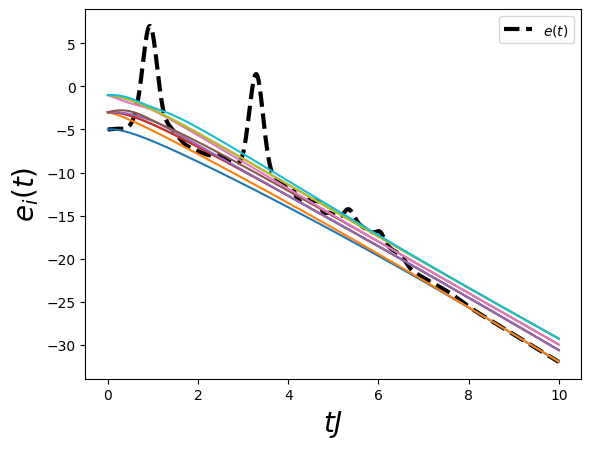

In [45]:
plt.plot(
    time, energy_optimal, color="black", linestyle="--", linewidth=3, label=r"$e(t)$"
)
for i in range(spectrum_optimalcontrol.shape[1]):

    plt.plot(time, spectrum_optimalcontrol[:, i])
plt.xlabel(r"$t J$", fontsize=20)
plt.ylabel(r"$e_i(t)$", fontsize=20)
plt.legend()
plt.show()

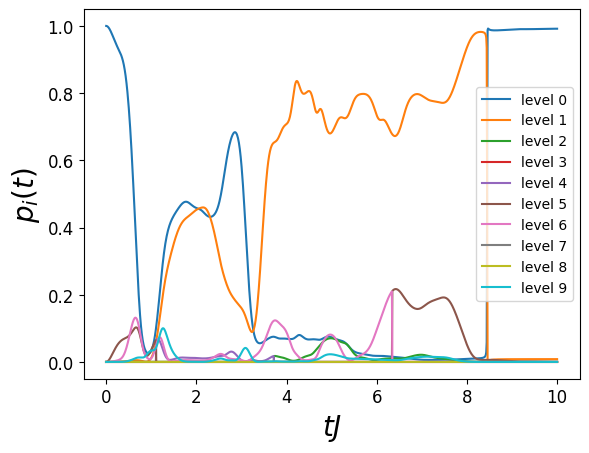

In [46]:
for i in range(nlevels):
    plt.plot(time, probabilities_optimalcontrol[:, i], label=f"level {i}")
plt.xlabel(r"$t J$", fontsize=20)
plt.ylabel(r"$p_i(t)$", fontsize=20)
plt.tick_params(axis="both", which="major", labelsize=12)
plt.legend()
plt.show()

##### Stabilizer Renyi Entropy

In [129]:
from tqdm import trange

# single state
magic_optimal_control = []
entanglememt_entropy_history_optimal_control = []
for i in trange(time_steps):
    state = psi_history_optimalcontrol[i]
    magic_optimal_control.append(sre((state)))
    entanglememt_entropy_history_optimal_control.append(
        entanglement_entropy.von_neumann((state))
    )

100%|██████████| 2500/2500 [00:01<00:00, 2074.55it/s]


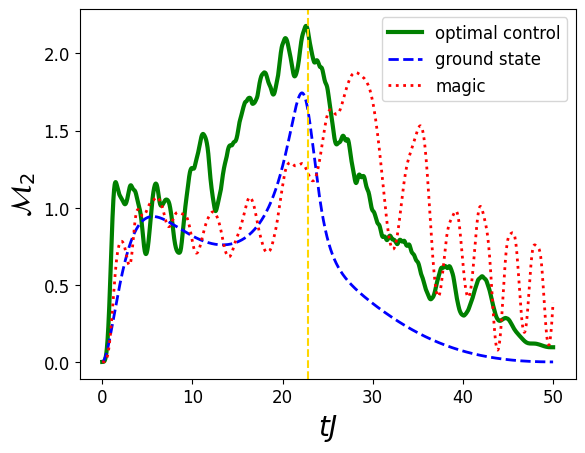

In [130]:
plt.plot(
    time,
    magic_optimal_control,
    label="optimal control",
    color="green",
    linestyle="-",
    linewidth=3,
)
plt.plot(
    time,
    magic_gs_level,
    label="ground state",
    color="blue",
    linestyle="--",
    linewidth=2,
)
plt.plot(time, magic, label="magic", color="red", linestyle=":", linewidth=2)
plt.axvline(min_time_gap, linestyle="--", color="gold")
plt.xlabel(r"$t J$", fontsize=20)
plt.ylabel(r"$\mathcal{M}_2$", fontsize=20)
plt.legend(fontsize=12)
plt.tick_params(axis="both", which="major", labelsize=12)
plt.show()

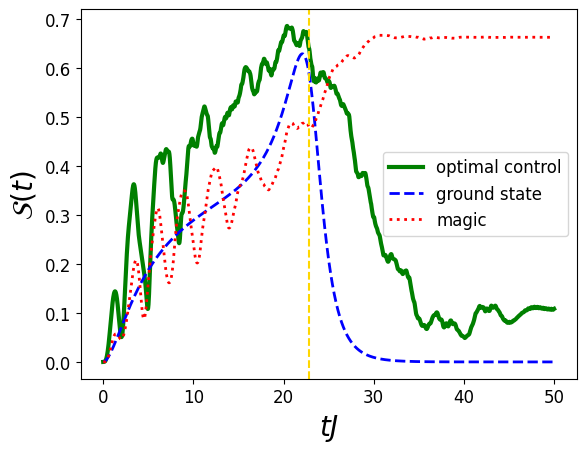

In [131]:
plt.plot(
    time,
    entanglememt_entropy_history_optimal_control,
    label="optimal control",
    color="green",
    linestyle="-",
    linewidth=3,
)
plt.plot(
    time,
    entanglement_entropy_gs_level_history,
    label="ground state",
    color="blue",
    linestyle="--",
    linewidth=2,
)
plt.plot(
    time,
    entanglememt_entropy_history,
    label="magic",
    color="red",
    linestyle=":",
    linewidth=2,
)
plt.axvline(min_time_gap, linestyle="--", color="gold")
plt.xlabel(r"$t J$", fontsize=20)
plt.ylabel(r"$\mathcal{S}(t)$", fontsize=20)
plt.legend(fontsize=12)
plt.tick_params(axis="both", which="major", labelsize=12)
plt.show()

##### Energy Path and NON-STABILIZERNESS through the optimization

[-31.59886864752997, -31.69409022631168, -31.73427015404568, -31.884896165160555, -31.89969862394582, -31.979004598412267, -32.140211034107615, -32.19279578029297, -32.21457472509181, -32.236663450751884, -32.258456557433554, -32.27338796349791, -32.28386209131259, -32.31004034448986, -32.37481176123249, -32.394962390601414, -32.41069977554195, -32.476808038536, -32.47913176808432, -32.48096193863215, -32.48107375988018]


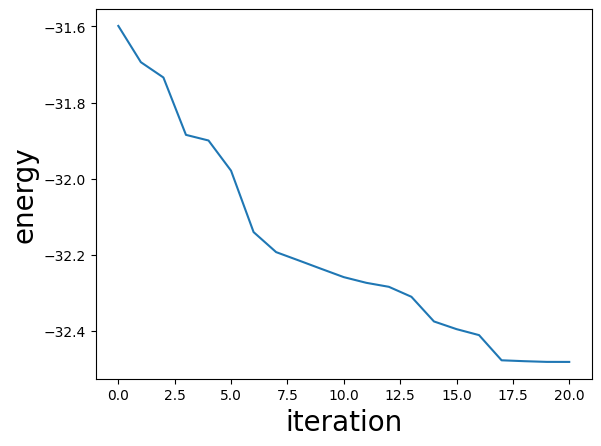

21
(2500,)


In [132]:
print(model.history)
plt.plot(np.arange(len(model.history)), model.history)
plt.xlabel("iteration", fontsize=20)
plt.ylabel("energy", fontsize=20)
# plt.yscale('log')
plt.show()
print(len(model.history))


print(model.history_drivings[0][0].shape)

In [133]:
total_magic = []
total_entanglement = []
delta_t = model.tf / model.nsteps
print(len(model.history_drivings[0]))
for i in trange(0, len(model.history_drivings), 1):

    h_driver, h_target = model.history_drivings[i]

    # initialization
    psi = psi_init.copy()
    psi_history_optimalcontrol = np.zeros(
        (time_steps, psi_init.shape[0]), dtype=complex
    )
    magic = []
    entanglement = []
    for i, t in enumerate(time):
        hamiltonian_t = (
            h_driver[i] * driver_hamiltonian + target_hamiltonian * h_target[i]
        )
        psi = expm_multiply(-1j * delta_t * hamiltonian_t, psi)
        psi_history_optimalcontrol[i] = psi
        magic.append(sre((psi)))
        entanglement.append(entanglement_entropy.von_neumann((psi)))
    total_magic.append(delta_t * np.sum(magic))
    total_entanglement.append(delta_t * np.sum(entanglement))

2


100%|██████████| 21/21 [00:58<00:00,  2.80s/it]


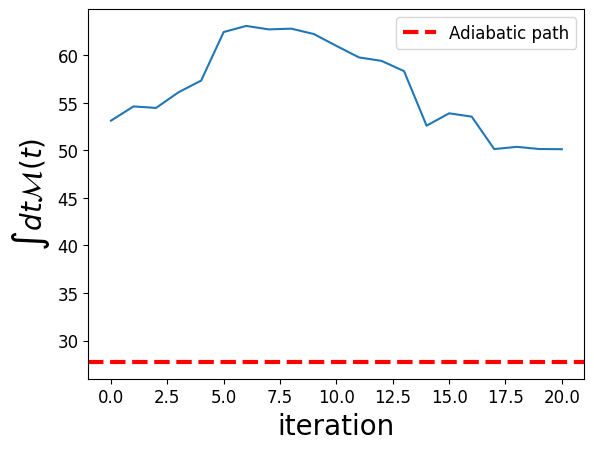

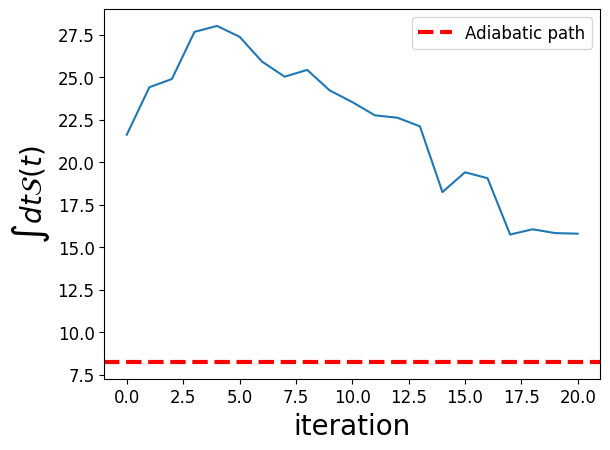

In [134]:
plt.plot(np.arange(len(total_magic)), total_magic)
plt.axhline(
    delta_t * np.sum(magic_gs_level),
    color="red",
    linestyle="--",
    linewidth=3,
    label="Adiabatic path",
)
plt.xlabel("iteration", fontsize=20)
plt.ylabel(r"$\int dt  \mathcal{M}(t) $", fontsize=20)
plt.legend(fontsize=12)
plt.tick_params(axis="both", which="major", labelsize=12)
plt.show()


plt.plot(np.arange(len(total_entanglement)), total_entanglement)
plt.axhline(
    delta_t * np.sum(entanglement_entropy_gs_level_history),
    color="red",
    linestyle="--",
    linewidth=3,
    label="Adiabatic path",
)
plt.xlabel("iteration", fontsize=20)
plt.ylabel(r"$\int dt  \mathcal{S}(t) $", fontsize=20)
plt.legend(fontsize=12)
plt.tick_params(axis="both", which="major", labelsize=12)
plt.show()


np.savez(
    f"data/history_optimal_control_{tau:.2f}.npz",
    total_magic=np.asarray(total_magic),
    total_entanglement=np.asarray(total_entanglement),
    energy=np.asarray(model.history),
)

##### Probabilities

In [135]:
from scipy.sparse.linalg import eigsh, expm_multiply

# ── initialization ────────────────────────────────────────────────────────────
energy_optimal_control = np.zeros(time_steps)
probabilities_optimal_control = np.zeros((time_steps, nlevels))

# ── time evolution ────────────────────────────────────────────────────────────
for i, t in enumerate(time):

    hamiltonian_t = (1 - t / tau) * driver_hamiltonian + (t / tau) * target_hamiltonian

    # ── diagonalize ───────────────────────────────────────────────────────
    eigenstates_raw = eigenstates_t[:, order].astype(complex)  # raw — for probabilities
    # overlap
    probabilities_optimal_control[i] = (
        np.einsum("i,ia->a", psi_history_optimalcontrol[i].conj(), eigenstates_raw)
        * np.einsum(
            "i,ia->a", psi_history_optimalcontrol[i].conj(), eigenstates_raw
        ).conj()
    )
    energy_optimal_control[i] = np.real(
        np.vdot(
            psi_history_optimalcontrol[i], hamiltonian_t @ psi_history_optimalcontrol[i]
        )
    )


print(probabilities_optimal_control[-1, 0])
print(spectrum.shape)
print(
    time[np.argmin(spectrum[:, 2] - spectrum[:, 0])],
    np.min(spectrum[:, 2] - spectrum[:, 0]),
)

min_time_gap = time[np.argmin(spectrum[:, 2] - spectrum[:, 0])]

/tmp/ipykernel_197304/98082351.py:15: ComplexWarning: Casting complex values to real discards the imaginary part
  probabilities_optimal_control[i] = (


0.9763367611965851
(2500, 10)
22.789115646258505 1.2211303264712026


##### Plot probabilities

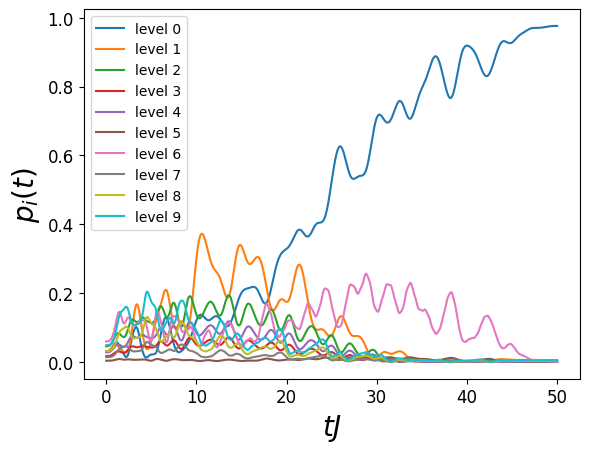

In [136]:
for i in range(nlevels):
    plt.plot(time, probabilities_optimal_control[:, i], label=f"level {i}")
plt.xlabel(r"$t J$", fontsize=20)
plt.ylabel(r"$p_i(t)$", fontsize=20)
plt.tick_params(axis="both", which="major", labelsize=12)
plt.legend()
plt.show()

##### Energy spectrum

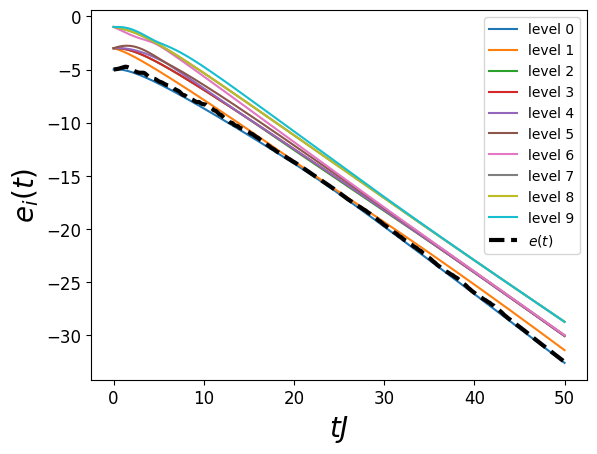

final energy: -32.48100899057115


In [137]:
for i in range(spectrum.shape[1]):
    plt.plot(time, spectrum[:, i], label=f"level {i}")
plt.plot(
    time,
    energy_optimal_control,
    color="black",
    linestyle="--",
    linewidth=3,
    label=r"$e(t)$",
)
plt.xlabel(r"$t J$", fontsize=20)
plt.ylabel(r"$e_i(t)$", fontsize=20)
plt.tick_params(axis="both", which="major", labelsize=12)
plt.legend()
plt.show()

print("final energy:", energy_optimal_control[-1])

## CounterAdiabatic Driving

##### We should be more careful about the CounterAdiabatic Driving, we need to be sure on the structure

Let's initialize the Catalyst term

In [39]:
from src.annealing_utils import get_unbiased_catalyst_term
from src.annealing_utils import get_counteradiabatic_term

counteradiabatic_term = get_counteradiabatic_term(
    driver_hamiltonian=driver_hamiltonian, target_hamiltonian=target_hamiltonian
)
counteradiabatic_term_s = PS.project(counteradiabatic_term)
print(counteradiabatic_term)

<Compressed Sparse Row sparse matrix of dtype 'complex128'
	with 192 stored elements and shape (64, 64)>
  Coords	Values
  (0, 1)	4j
  (0, 2)	4j
  (0, 4)	4j
  (0, 8)	4j
  (0, 16)	4j
  (0, 32)	4j
  (1, 0)	(-0-4j)
  (1, 5)	4j
  (1, 9)	4j
  (1, 17)	4j
  (2, 0)	(-0-4j)
  (2, 10)	4j
  (2, 18)	4j
  (2, 34)	4j
  (3, 11)	4j
  (3, 19)	4j
  (4, 0)	(-0-4j)
  (4, 5)	4j
  (4, 20)	4j
  (4, 36)	4j
  (5, 1)	(-0-4j)
  (5, 4)	(-0-4j)
  (5, 7)	(-0-4j)
  (5, 21)	4j
  (6, 22)	4j
  :	:
  (57, 41)	4j
  (58, 42)	4j
  (58, 56)	(-0-4j)
  (58, 59)	(-0-4j)
  (58, 62)	(-0-4j)
  (59, 27)	4j
  (59, 43)	4j
  (59, 58)	4j
  (59, 63)	(-0-4j)
  (60, 44)	4j
  (60, 52)	4j
  (61, 29)	4j
  (61, 45)	4j
  (61, 53)	4j
  (61, 63)	(-0-4j)
  (62, 46)	4j
  (62, 54)	4j
  (62, 58)	4j
  (62, 63)	(-0-4j)
  (63, 31)	4j
  (63, 47)	4j
  (63, 55)	4j
  (63, 59)	4j
  (63, 61)	4j
  (63, 62)	4j


Compute the optimal driving of the adiabatic gauge potential from calculations

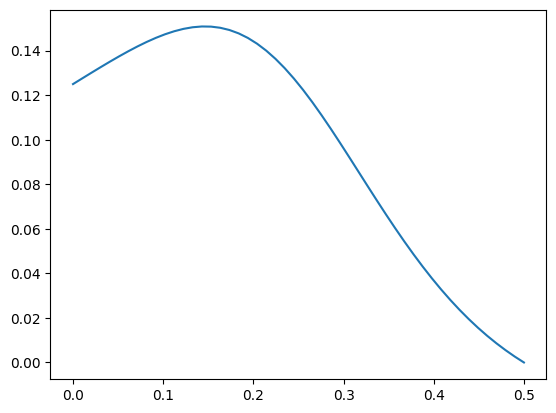

In [40]:
def optimal_alpha(J, lam):
    """
    Optimal alpha_0(lambda) from minimizing Tr[G_lambda^2].
    """
    J2 = np.sum(J**2)  # ||J||^2
    J2_row = np.sum(J**2, axis=1)  # (n,): sum_B J_AB^2
    J4_sum = np.sum(J2_row**2)  # sum_A (sum_B J_AB^2)^2

    numerator = 4 * (1 - lam) * J2
    denominator = 32 * (1 - lam) ** 2 * J2 + 16 * lam**2 * J4_sum

    if np.abs(denominator) < 1e-12:
        return 0.0
    return -numerator / denominator


# schedule of alpha_0 along the annealing
alpha = -1 * np.array([optimal_alpha(jij, s) for s in time / tau])

plt.plot(time, alpha)
plt.show()

In [22]:
from scipy.sparse.linalg import eigsh, expm_multiply
from src.annealing_utils import compute_exact_AGP

# ── initial state ─────────────────────────────────────────────────────────────
dim = 2**nqubits
psi_init = np.ones(dim, dtype=complex) / np.sqrt(dim)


# initialization

psi = psi_init.copy()
psi_history_counteradiabatic = np.zeros((time_steps, psi_init.shape[0]), dtype=complex)
spectrum_counteradiabatic = np.zeros((time_steps, nlevels))
energy_counteradiabatic = np.zeros(time_steps)
for i, t in enumerate(time):
    exact_AGP = compute_exact_AGP(
        driver_hamiltonian=driver_hamiltonian,
        target_hamiltonian=target_hamiltonian,
        lam=t / tau,
        n_eigs=2,
    )
    hamiltonian_t = (
        (1 - t / tau) * driver_hamiltonian
        + target_hamiltonian * t / tau
        + (1 / tau) * exact_AGP
    )
    psi = expm_multiply(-1j * delta_t * hamiltonian_t, psi)
    spectrum_t, _ = eigsh(hamiltonian_t, which="SA", k=nlevels)
    order = np.argsort(spectrum_t)
    spectrum_t = spectrum_t[order]
    spectrum_counteradiabatic[i] = spectrum_t
    energy_counteradiabatic[i] = psi.conj().dot(hamiltonian_t.dot(psi))
    # sort both by eigenvalue
    psi_history_counteradiabatic[i] = psi

/tmp/ipykernel_197304/3322144027.py:32: ComplexWarning: Casting complex values to real discards the imaginary part
  energy_counteradiabatic[i] = psi.conj().dot(hamiltonian_t.dot(psi))


In [42]:
# initialize the state


# initialization
energy_counteradiabatic_linear_hamiltonian = np.zeros(time_steps)
probabilities_counteradiabatic = np.zeros((time_steps, nlevels))
for i, t in enumerate(time):
    psi = psi_history_counteradiabatic[i]
    hamiltonian_t_linear = (
        1 - t / tau
    ) * driver_hamiltonian_s + target_hamiltonian_s * t / tau
    values, eigenstates = eigsh(hamiltonian_t_linear, which="SA", k=nlevels)
    order = np.argsort(values)
    spectrum_t = values[order]
    eigenstates_t = eigenstates[:, order]
    # overlap
    probabilities_counteradiabatic[i] = (
        np.einsum("i,ia->a", psi.conj(), eigenstates_t)
        * np.einsum("i,ia->a", psi.conj(), eigenstates_t).conj()
    )

    energy_counteradiabatic_linear_hamiltonian[i] = psi.conj().dot(
        hamiltonian_t_linear.dot(psi)
    )
print(t)
print(psi.conj().dot(target_hamiltonian_s.dot(psi)))
print(energy_counteradiabatic_linear_hamiltonian[-1])
print(probabilities_counteradiabatic[-1, 0])

0.5
(-2.5510140722121797+0j)
-2.5510140722121797
0.38111463695270953


/tmp/ipykernel_2880/614686986.py:17: ComplexWarning: Casting complex values to real discards the imaginary part
  probabilities_counteradiabatic[i] = (
/tmp/ipykernel_2880/614686986.py:22: ComplexWarning: Casting complex values to real discards the imaginary part
  energy_counteradiabatic_linear_hamiltonian[i] = psi.conj().dot(


##### Results of the unbiased counteradiabatic term

0
-6.000000000000003
-2.5510140722121797
1
-2.0
-2.5510140722121797
2
-2.0
-2.5510140722121797
3
-2.0
-2.5510140722121797
4
-2.0
-2.5510140722121797
5
-2.0
-2.5510140722121797
6
-1.9999999999999998
-2.5510140722121797
7
-1.9999999999999998
-2.5510140722121797
8
-1.9999999999999996
-2.5510140722121797
9
-1.9999999999999996
-2.5510140722121797


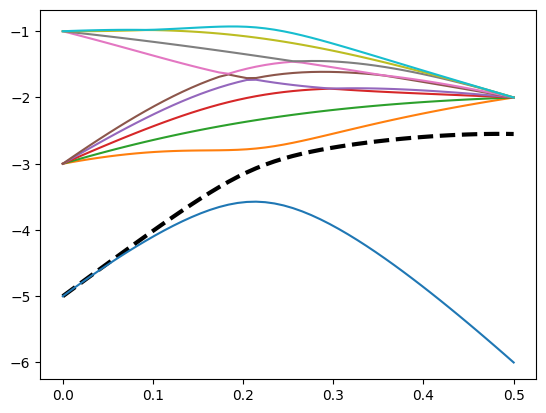

0
-6.009373812628143
1
-2.0000000000000004
2
-2.0000000000000004
3
-2.0000000000000004
4
-2.0
5
-2.0
6
-2.0
7
-2.0
8
-1.9999999999999998
9
-1.9999999999999998


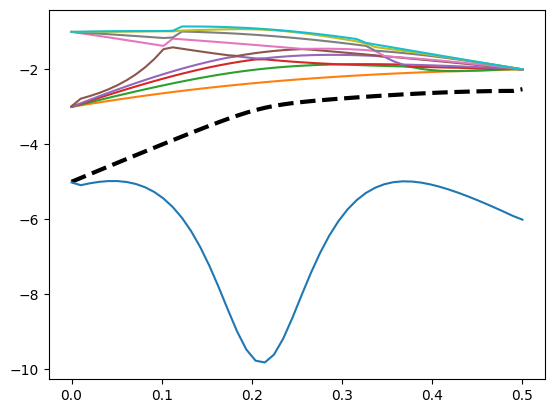

In [43]:
plt.plot(
    time,
    energy_counteradiabatic_linear_hamiltonian,
    color="black",
    linestyle="--",
    linewidth=3,
)
for i in range(spectrum_counteradiabatic.shape[1]):
    print(i)
    print(spectrum[-1, i])
    print(energy_counteradiabatic_linear_hamiltonian[-1])
    plt.plot(time, spectrum[:, i])

plt.show()

plt.plot(time, energy_counteradiabatic, color="black", linestyle="--", linewidth=3)
for i in range(spectrum_counteradiabatic.shape[1]):

    print(i)
    print(spectrum_counteradiabatic[-1, i])
    plt.plot(time, spectrum_counteradiabatic[:, i])

plt.show()

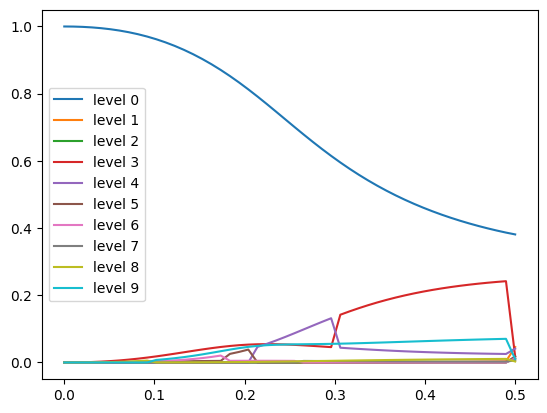

In [44]:
for i in range(nlevels):
    plt.plot(time, probabilities_counteradiabatic[:, i], label=f"level {i}")

plt.legend()
plt.show()

##### Measure of Stabilizerness

In [45]:
# single state
magic_counteradiabatic = []

for i in trange(time_steps):
    state = psi_history_counteradiabatic[i]
    magic_counteradiabatic.append(sre(PS.lift(state)))

100%|██████████| 50/50 [00:00<00:00, 868.12it/s]


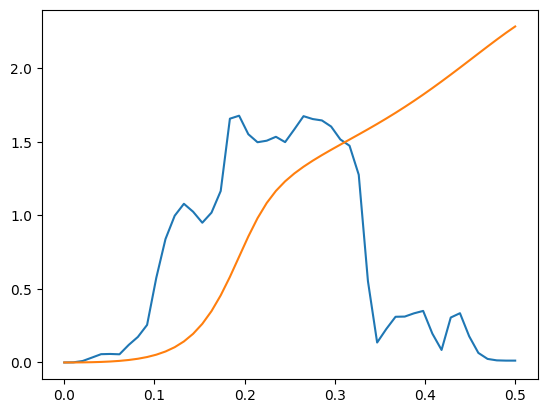

In [46]:
plt.plot(time, magic)
# plt.plot(time,magic_optimal_control)
plt.plot(time, magic_counteradiabatic)
plt.show()

## Non-stoquastic Driving

##### We should be more careful about the CounterAdiabatic Driving, we need to be sure on the structure

Let's initialize the Catalyst term

In [55]:
from src.annealing_utils import get_unbiased_catalyst_term
from src.annealing_utils import get_counteradiabatic_term
from ManyBodyQutip.qutip_class import SpinOperator

js = np.random.choice([-1, 1], size=(nqubits, nqubits))

nonstoquastic_driving = 0.0
for i in range(nqubits):
    # nonstoquastic_driving+=SpinOperator(index=[('x',i)],coupling=[(-1)**(i)],size=nqubits).qutip_op.data_as('csr_matrix')
    for j in range(i + 1, nqubits):
        nonstoquastic_driving += SpinOperator(
            index=[("x", i, "x", j)], coupling=[js[i, j]], size=nqubits
        ).qutip_op.data_as("csr_matrix")
        # nonstoquastic_driving+=SpinOperator(index=[('y',i,'y',j)],coupling=[(0.5)],size=nqubits).qutip_op.data_as('csr_matrix')

nonstoquastic_driving_s = PS.project(nonstoquastic_driving)

In [57]:
from scipy.sparse.linalg import eigsh, expm_multiply

# combined driver: H_D + beta * H_NS
beta = 1
total_driver_ns = driver_hamiltonian_s


print(total_driver_ns)
_, eigvecs = eigsh(total_driver_ns.astype(complex), which="SA", k=2)
psi_init = eigvecs[:, 0].astype(complex)

# psi_init       = np.ones(total_driver_ns.shape[0], dtype=complex) / np.sqrt(total_driver_ns.shape[0])
e_check = (psi_init.conj() @ total_driver_ns @ psi_init).real
print(f"GS energy check: {e_check:.6f}")  # should match evals[0]

# initialization

psi = psi_init
psi_history_catalyst = np.zeros((time_steps, psi_init.shape[0]), dtype=complex)
spectrum_catalyst = np.zeros((time_steps, nlevels))
energy_catalyst = np.zeros(time_steps)
for i, t in enumerate(time):
    psi_history_catalyst[i] = psi
    hamiltonian_t = (
        (1 - t / tau) * total_driver_ns
        + target_hamiltonian_s * t / tau
        + (1 - t / tau) * (t / tau) * nonstoquastic_driving_s
    )
    psi = expm_multiply(-1j * delta_t * hamiltonian_t, psi)
    spectrum_t, _ = eigsh(hamiltonian_t, which="SA", k=nlevels)
    order = np.argsort(spectrum_t)
    spectrum_t = spectrum_t[order]
    spectrum_catalyst[i] = spectrum_t
    energy_catalyst[i] = psi.conj().dot(hamiltonian_t.dot(psi))
    # sort both by eigenvalue

<Compressed Sparse Row sparse matrix of dtype 'complex128'
	with 160 stored elements and shape (32, 32)>
  Coords	Values
  (0, 1)	(-1+0j)
  (0, 2)	(-1+0j)
  (0, 4)	(-1+0j)
  (0, 8)	(-1+0j)
  (0, 16)	(-1+0j)
  (1, 0)	(-1+0j)
  (1, 3)	(-1+0j)
  (1, 5)	(-1+0j)
  (1, 9)	(-1+0j)
  (1, 17)	(-1+0j)
  (2, 0)	(-1+0j)
  (2, 3)	(-1+0j)
  (2, 6)	(-1+0j)
  (2, 10)	(-1+0j)
  (2, 18)	(-1+0j)
  (3, 1)	(-1+0j)
  (3, 2)	(-1+0j)
  (3, 7)	(-1+0j)
  (3, 11)	(-1+0j)
  (3, 19)	(-1+0j)
  (4, 0)	(-1+0j)
  (4, 5)	(-1+0j)
  (4, 6)	(-1+0j)
  (4, 12)	(-1+0j)
  (4, 20)	(-1+0j)
  :	:
  (27, 11)	(-1+0j)
  (27, 19)	(-1+0j)
  (27, 25)	(-1+0j)
  (27, 26)	(-1+0j)
  (27, 31)	(-1+0j)
  (28, 12)	(-1+0j)
  (28, 20)	(-1+0j)
  (28, 24)	(-1+0j)
  (28, 29)	(-1+0j)
  (28, 30)	(-1+0j)
  (29, 13)	(-1+0j)
  (29, 21)	(-1+0j)
  (29, 25)	(-1+0j)
  (29, 28)	(-1+0j)
  (29, 31)	(-1+0j)
  (30, 14)	(-1+0j)
  (30, 22)	(-1+0j)
  (30, 26)	(-1+0j)
  (30, 28)	(-1+0j)
  (30, 31)	(-1+0j)
  (31, 15)	(-1+0j)
  (31, 23)	(-1+0j)
  (31, 27)	(-1+0j)
  (

/tmp/ipykernel_2880/3358782213.py:34: ComplexWarning: Casting complex values to real discards the imaginary part
  energy_catalyst[i] = psi.conj().dot(hamiltonian_t.dot(psi))


In [58]:
# initialize the state


# initialization
energy_catalyst_linear_hamiltonian = np.zeros(time_steps)
probabilities_nonstoquastic = np.zeros((time_steps, nlevels))
for i, t in enumerate(time):
    psi = psi_history_catalyst[i]
    hamiltonian_t_linear = (
        1 - t / tau
    ) * total_driver_ns + target_hamiltonian_s * t / tau
    values, eigenstates = eigsh(hamiltonian_t_linear, which="SA", k=nlevels)
    order = np.argsort(values)
    spectrum_t = values[order]
    eigenstates_t = eigenstates[:, order]
    # overlap
    probabilities_nonstoquastic[i] = (
        np.einsum("i,ia->a", psi.conj(), eigenstates_t)
        * np.einsum("i,ia->a", psi.conj(), eigenstates_t).conj()
    )

    energy_catalyst_linear_hamiltonian[i] = psi.conj().dot(
        hamiltonian_t_linear.dot(psi)
    )
print(t)
print(psi.conj().dot(target_hamiltonian_s.dot(psi)))
print(probabilities_nonstoquastic[-1, 0])

0.5
(-0.4594679562259469+0j)
0.04765695725410843


/tmp/ipykernel_2880/1015930268.py:17: ComplexWarning: Casting complex values to real discards the imaginary part
  probabilities_nonstoquastic[i] = (
/tmp/ipykernel_2880/1015930268.py:22: ComplexWarning: Casting complex values to real discards the imaginary part
  energy_catalyst_linear_hamiltonian[i] = psi.conj().dot(


##### Results of the unbiased catalyst

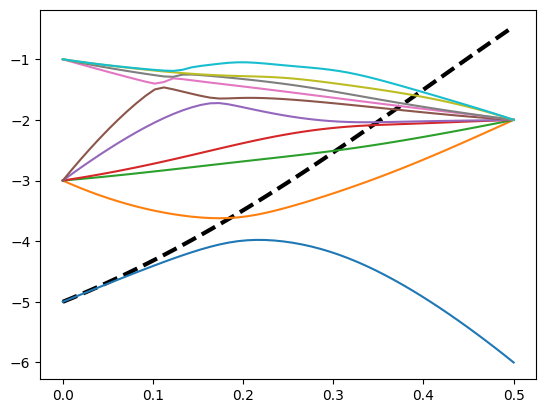

In [59]:
plt.plot(time, energy_catalyst, color="black", linestyle="--", linewidth=3)
for i in range(spectrum_catalyst.shape[1]):

    plt.plot(time, spectrum_catalyst[:, i])

plt.show()

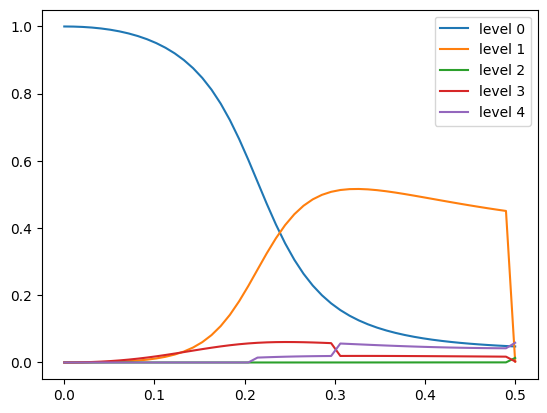

In [60]:
for i in range(nlevels // 2):
    plt.plot(time, probabilities_nonstoquastic[:, i], label=f"level {i}")

plt.legend()
plt.show()

In [ ]:
from src.jax_utils import SREJax
from tqdm import trange

# build once — reuse for all states
sre = SREJax(n_qubits=nqubits, batch_size=4096)

# single state
magic_nonstoquastic = []
for i in trange(time_steps):
    state = psi_history_catalyst[i]
    magic_nonstoquastic.append(sre(PS.lift(state)))

Building Pauli tables for n=6 (4096 Paulis)...
Done.


  0%|          | 0/300 [00:00<?, ?it/s]

100%|██████████| 300/300 [00:00<00:00, 399.41it/s]


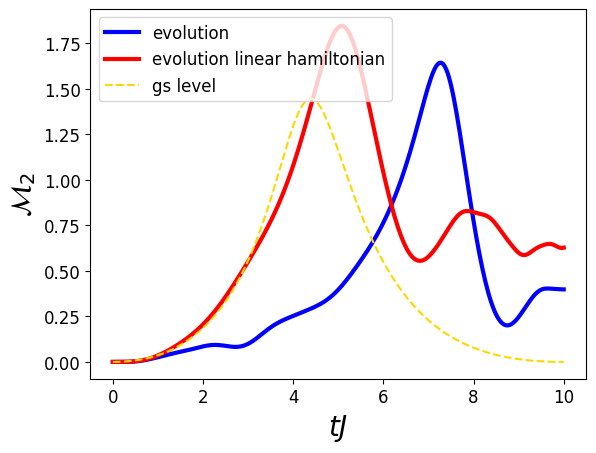

In [ ]:
plt.plot(
    time,
    magic_nonstoquastic,
    label="evolution",
    color="blue",
    linestyle="-",
    linewidth=3,
)
plt.plot(
    time,
    magic,
    label="evolution linear hamiltonian",
    color="red",
    linestyle="-",
    linewidth=3,
)
plt.plot(time, magic_gs_level, label="gs level", linestyle="--", color="gold")
plt.xlabel(r"$t J$", fontsize=20)
plt.ylabel(r"$\mathcal{M}_2$", fontsize=20)
plt.legend(fontsize=12)
plt.tick_params(axis="both", which="major", labelsize=12)
plt.show()

## Quench Limit

In [ ]:
# ── time evolution parameters ─────────────────────────────────────────────────
nlevels = 10
tau = 10
time_steps = int(10 * tau)
time = np.linspace(0, tau, time_steps)
delta_t = time[1] - time[0]

In [ ]:
from scipy.sparse.linalg import eigsh, expm_multiply

# ── initial state ─────────────────────────────────────────────────────────────
_, eigvecs = eigsh(driver_hamiltonian_s, which="SA", k=2)
psi_init = eigvecs[:, 0].astype(complex)

# ── initialization ────────────────────────────────────────────────────────────
tau_q = 0.1 * tau
psi_history_quench = np.zeros((time_steps, dim // 2), dtype=complex)

eigenstates_prev = None
psi = psi_init.copy()

# ── time evolution ────────────────────────────────────────────────────────────
for i, t in enumerate(time):
    psi_history_quench[i] = psi
    hamiltonian_t = (t / tau) * target_hamiltonian_s + np.max(
        (1 - t / tau_q), 0
    ) * driver_hamiltonian_s
    psi = expm_multiply(-1j * delta_t * hamiltonian_t, psi)

In [ ]:
from src.jax_utils import SREJax
from tqdm import trange

# build once — reuse for all states
sre = SREJax(n_qubits=nqubits, batch_size=4096)
entanglement_entropy = EntanglementEntropy(nqubits=nqubits, n_A=nqubits // 2)
# single state
magic_quench = []
entanglement_entropy_history_quench = []
for i in trange(time_steps):
    state = psi_history_quench[i]
    magic_quench.append(sre(PS.lift(state)))
    entanglement_entropy_history_quench.append(
        entanglement_entropy.von_neumann(PS.lift(state))
    )

Building Pauli tables for n=8 (65536 Paulis)...
Done.
Bipartition: A=4 qubits (16d), B=4 qubits (16d)


100%|██████████| 100/100 [00:29<00:00,  3.35it/s]


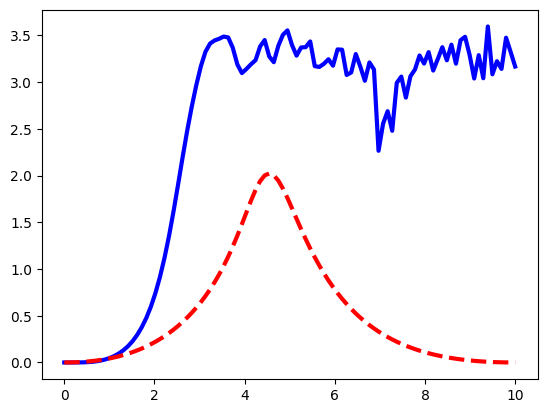

In [ ]:
plt.plot(time, magic_quench, label="quench", color="blue", linestyle="-", linewidth=3)
plt.plot(
    time, magic_gs_level, label="gs level", color="red", linestyle="--", linewidth=3
)

plt.show()

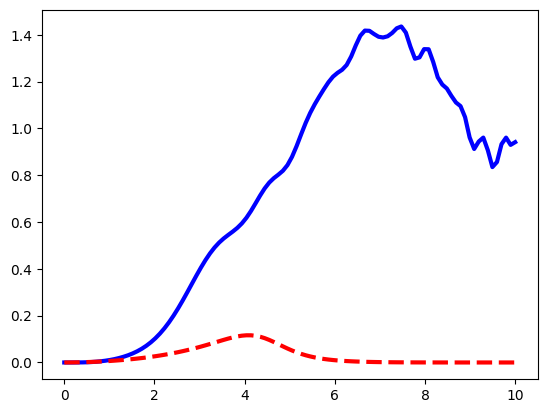

In [ ]:
plt.plot(
    time,
    entanglement_entropy_history_quench,
    label="quench",
    color="blue",
    linestyle="-",
    linewidth=3,
)
plt.plot(
    time,
    entanglement_entropy_gs_level_history,
    label="gs level",
    color="red",
    linestyle="--",
    linewidth=3,
)

plt.show()

## Result analysis

In [51]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
tau = 30
nqubits = 6

data = np.load(f"magic_annealing_results_qubit_{nqubits}_tau_{tau:.1f}.npz")

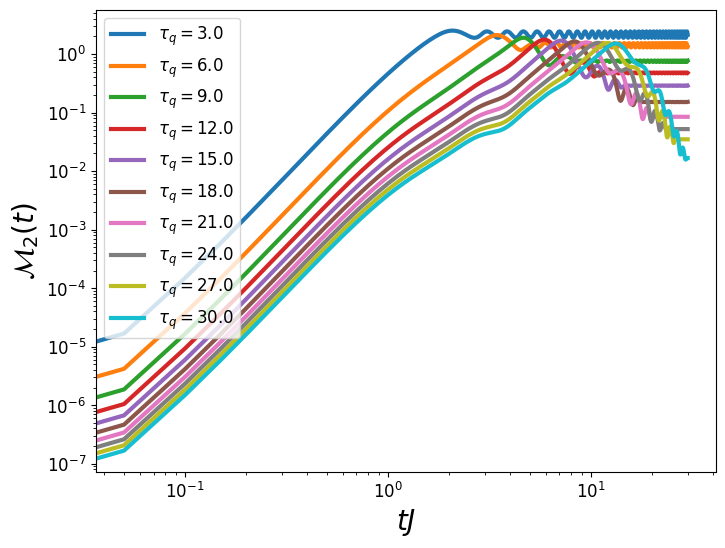

In [ ]:
magic_list = data["magic_list"]
magic_gs_level_list = data["magic_gs_level_list"]
time = data["time"]
tau_qs = data["tau_qs"]
plt.figure(figsize=(8, 6))
for i in range(len(magic_list)):
    plt.plot(
        time,
        magic_list[i],
        label=r"$\tau_q=$" + f"{tau_qs[i]:.1f}",
        linestyle="-",
        linewidth=3,
    )
# plt.plot(time,magic_gs_level_list[0],label='gs level',color='red',linestyle='--',linewidth=3)
plt.xlabel(r"$t J$", fontsize=20)
plt.ylabel(r"$\mathcal{M}_2 (t)$", fontsize=20)
plt.legend(fontsize=12)
plt.loglog()
plt.tick_params(axis="both", which="major", labelsize=12)
plt.show()

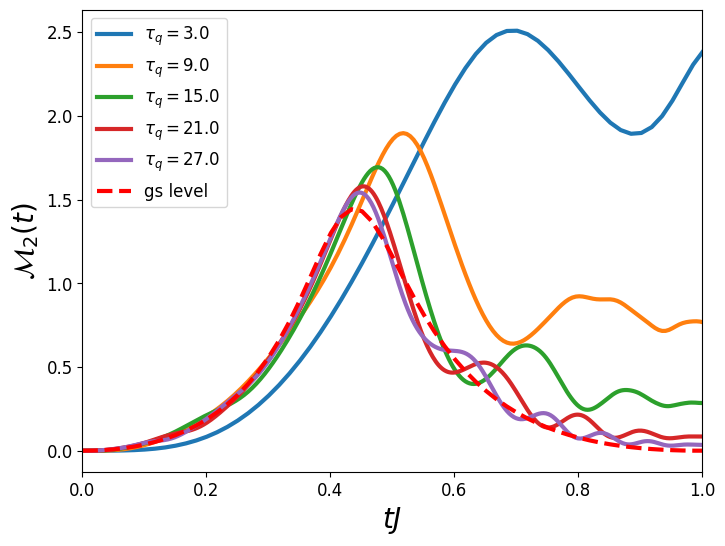

In [ ]:
magic_list = data["magic_list"]
magic_gs_level_list = data["magic_gs_level_list"]
time = data["time"]
tau_qs = data["tau_qs"]
plt.figure(figsize=(8, 6))
for i in range(0, len(magic_list), 2):
    plt.plot(
        time / tau_qs[i],
        magic_list[i],
        label=r"$\tau_q=$" + f"{tau_qs[i]:.1f}",
        linestyle="-",
        linewidth=3,
    )
plt.plot(
    time / tau_qs[0],
    magic_gs_level_list[0],
    label="gs level",
    color="red",
    linestyle="--",
    linewidth=3,
)
plt.xlim(0, 1)
plt.xlabel(r"$t J$", fontsize=20)
plt.ylabel(r"$\mathcal{M}_2 (t)$", fontsize=20)
plt.legend(fontsize=12)

plt.tick_params(axis="both", which="major", labelsize=12)
plt.show()

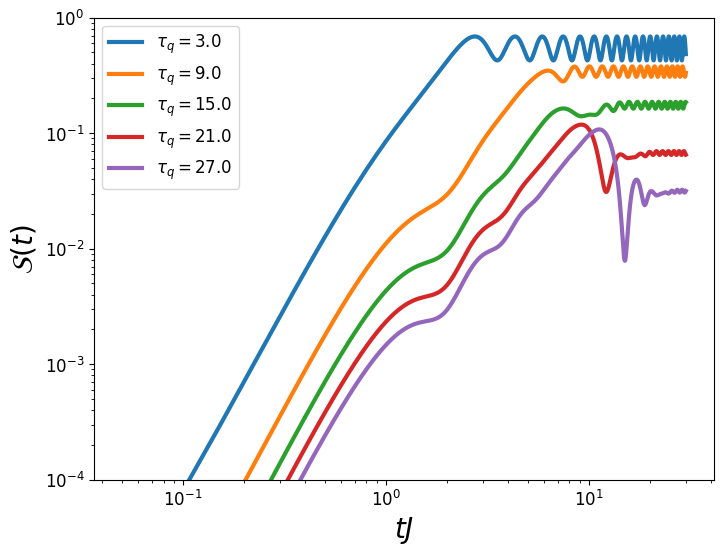

In [ ]:
entanglement_entropy_history_list = data["entanglement_entropy_history_quench_list"]
entanglement_entropy_gs_level_history = data[
    "entanglement_entropy_gs_level_history_list"
]
time = data["time"]
tau_qs = data["tau_qs"]
plt.figure(figsize=(8, 6))
for i in range(0, len(entanglement_entropy_history_list), 2):
    plt.plot(
        time,
        entanglement_entropy_history_list[i],
        label=r"$\tau_q=$" + f"{tau_qs[i]:.1f}",
        linestyle="-",
        linewidth=3,
    )
# plt.plot(time,magic_gs_level_list[0],label='gs level',color='red',linestyle='--',linewidth=3)
plt.xlabel(r"$t J$", fontsize=20)
plt.ylabel(r"$\mathcal{S} (t)$", fontsize=20)
plt.legend(fontsize=12)
plt.loglog()
plt.tick_params(axis="both", which="major", labelsize=12)
plt.ylim(10**-4, 10**0)
plt.show()

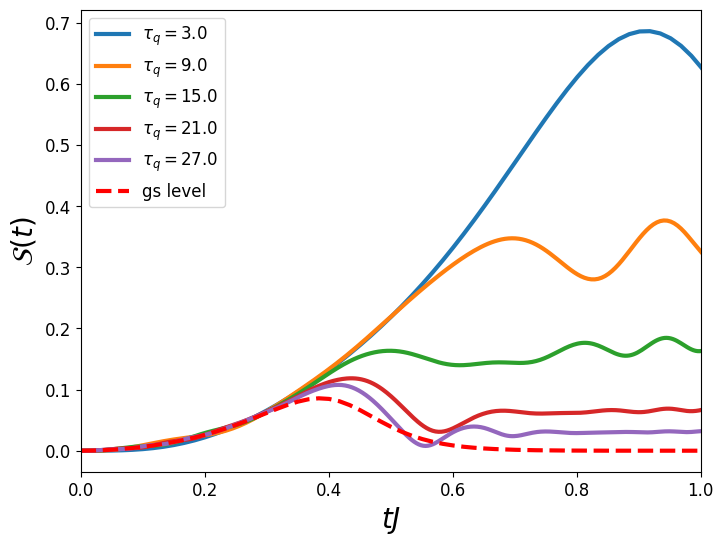

In [ ]:
entanglement_entropy_gs_level_history = data[
    "entanglement_entropy_gs_level_history_list"
]
time = data["time"]
tau_qs = data["tau_qs"]
plt.figure(figsize=(8, 6))
for i in range(0, len(entanglement_entropy_history_list), 2):
    plt.plot(
        time / tau_qs[i],
        entanglement_entropy_history_list[i],
        label=r"$\tau_q=$" + f"{tau_qs[i]:.1f}",
        linestyle="-",
        linewidth=3,
    )
plt.plot(
    time / tau_qs[0],
    entanglement_entropy_gs_level_history[0],
    label="gs level",
    color="red",
    linestyle="--",
    linewidth=3,
)
plt.xlim(0, 1)
plt.xlabel(r"$t J$", fontsize=20)
plt.ylabel(r"$\mathcal{S} (t)$", fontsize=20)
plt.legend(fontsize=12)
plt.tick_params(axis="both", which="major", labelsize=12)
plt.show()